In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import suncalc

import dask.dataframe as dd
from pathlib import Path
from tqdm import tqdm
import re
import pytz

import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/activity")

In [3]:
import subsampling as ss
import activity_assembly as actvt
import bout.assembly as bt
import comparison.data_assembly as comp
import comparison.plot as complot
from core import SITE_NAMES

from cli import get_file_paths
import plot
import pipeline

In [4]:
avail = np.arange(0, 180, 2) + 2
reset_3 = avail[np.where((3*60 % avail) == 0)[0]]
reset_4 = avail[np.where((4*60 % avail) == 0)[0]]
reset_6 = avail[np.where((6*60 % avail) == 0)[0]]
reset_12 = avail[np.where((12*60 % avail) == 0)[0]]
reset_24 = avail[np.where((24*60 % avail) == 0)[0]]

In [5]:
dt_starts = {'Carp high':dt.datetime(2022, 7, 15, 3, 0, 0),
             'Carp low':dt.datetime(2022, 9, 15, 0, 0, 0),
           'Telephone high':dt.datetime(2022, 8, 20, 3, 0, 0),
           'Telephone low':dt.datetime(2022, 9, 17, 0, 0, 0),
             'Central':dt.datetime(2022, 7, 10, 0, 0, 0),
             'Foliage':dt.datetime(2022, 7, 10, 0, 0, 0)}
dt_ends = {'Carp high':dt.datetime(2022, 8, 15, 13, 0, 0),
           'Carp low':dt.datetime(2022, 10, 15, 0, 0, 0),
           'Telephone high':dt.datetime(2022, 9, 20, 13, 0, 0),
           'Telephone low':dt.datetime(2022, 10, 17, 13, 0, 0),
           'Central':dt.datetime(2022, 10, 30, 16, 0, 0),
           'Foliage':dt.datetime(2022, 10, 30, 16, 0, 0)}
high_activity_types = {'Carp':'LF', 'Telephone':'HF'}

In [6]:
step = 1/10
step_by = np.arange(step, 1, step)
# step_by = step_by[step_by>=(1/6)]
step_by

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [7]:
step = 1/6
step_by = np.arange(0, (2/3)+step, step)
step_by = step_by[step_by>=(1/6)]
step_by

array([0.16666667, 0.33333333, 0.5       , 0.66666667])

In [8]:
cycle_lengths = [6, 10, 30, 48, 60, 72, 90]
percent_ons = step_by
data_params = dict()
data_params["cycle_lengths"] = cycle_lengths
data_params["percent_ons"] = percent_ons
dc_tags = ss.get_list_of_dc_tags(cycle_lengths, percent_ons)

In [58]:
def test_true_100_at_factor(points_dc, points_c, p):
    test_dc = points_dc[points_dc!=0].dropna()
    test_c = points_c.loc[test_dc.index]
    filt_dc = (test_dc.values>test_c.values*(1+p))|(test_dc.values<test_c.values*(1-p))
    assert filt_dc.all()==False

def get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb):
    points_dc = pd.DataFrame(plt_dcmetr.values, columns=['values'], index=plt_dcmetr.index)
    points_c = pd.DataFrame(plt_cmetr.values, columns=['values'], index=plt_cmetr.index)
    points_c = points_c[points_c>=(10/30)].dropna()
    points_dc = points_dc.loc[points_c.index]
    total_num_points = points_dc.shape[0]

    axis = 1
    within_bounds = ((points_dc.values<=points_c.values*(axis+(upb*p)))&(points_dc.values>=points_c.values*(axis-p)))
    num_points_in_bounds = np.sum(within_bounds.astype(int), axis=0)
    percent_points_in_bounds = num_points_in_bounds / total_num_points
    # all_points_bound = p[percent_points_in_bounds==1][0]
    # test_true_100_at_factor(points_dc, points_c, all_points_bound)

    return percent_points_in_bounds

def plot_percent_within_bounds_curve_for_metric(ax, plt_dc_metr, plt_c_metr, data_params):
    frac = float(re.findall(r"(\d.\d+)", plt_dc_metr.columns[0])[0])
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]
    percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dc_metr, plt_c_metr, p, 1.0)

    if data_params['metric_tag']=='call_rate':
        col = 'red'
    elif data_params['metric_tag']=='activity_index':
        col = 'royalblue'
    else:
        col = 'green'

    points_on_line = percent_points_in_bounds[p_inds]
    ax.plot(100*p, 100*percent_points_in_bounds, label=f'{round(100*points_on_line)}% captured',
                color=col, linewidth=3, alpha=0.8)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

In [61]:
def plot_indiv_dc_control_comp_over_cycle_linear_scale(ax, single_col_dc_metr1, single_col_c_metr, data_params):
    single_col_dc_metr1.index = pd.DatetimeIndex(single_col_dc_metr1.index)
    dc_metr1 = pd.pivot_table(single_col_dc_metr1, index=(single_col_dc_metr1.index.time), 
                        columns=single_col_dc_metr1.index.date, 
                        values=single_col_dc_metr1.columns[0])
    single_col_c_metr.index = pd.DatetimeIndex(single_col_c_metr.index)
    paired_col_c_metr = single_col_c_metr[(~single_col_dc_metr1.isna()).values]
    c_metr = pd.pivot_table(paired_col_c_metr, index=(paired_col_c_metr.index.time), 
                    columns=paired_col_c_metr.index.date, 
                    values=paired_col_c_metr.columns[0])
    ax.grid(which='both')
    if data_params['metric_tag']=='call_rate':
        col = 'red'
        units = 'calls/min'
    elif data_params['metric_tag']=='activity_index':
        col = 'royalblue'
        units = '%'
    else:
        col = 'green'
        units = '%'
    frac = float(re.findall(r"\d.\d+", single_col_dc_metr1.columns[0])[0])
    c_metr_max = c_metr.max().max()
    ax.plot([0, 100*c_metr_max], [0, 100*c_metr_max], linestyle='dashed', color='k', label='line-of-unity')
    
    ax.scatter(c_metr, dc_metr1, color=col, edgecolors='k', s=80, alpha=0.8)
    ax.set_xlabel(f'True values ({units})')
    ax.set_ylabel(f'Reduced estimate ({units})')
    upper_lim = 400
    if (data_params['metric_tag'] == 'call_rate'):
        ax.set_xlim(0, upper_lim)
        ax.set_ylim(0, upper_lim)
    else:
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_xticks(np.arange(0, 110, 20))
        ax.set_yticks(np.arange(0, 110, 20))

In [11]:
site_keys = ['Carp']
type_keys = ['LF']
data_params["dc_tags"] = dc_tags
data_params['cur_dc_tag'] = '30of30'
data_params['recording_start'] = '00:00'
data_params['recording_end'] = '16:00'
data_params['assembly_type'] = 'kmeans'
site_key = site_keys[0]
type_key = type_keys[0]

type_key = high_activity_types[site_key]
actvt_key = 'high'
data_params['start'] = dt_starts[f'{site_key} {actvt_key}']
data_params['end'] = dt_ends[f'{site_key} {actvt_key}']
data_params['P'] = 0.4

In [65]:
def add_noise_to_group(group, frac):
    noise_df = pd.DataFrame()
    noise_start_times = np.random.uniform(0, 1800, np.floor(frac*group.shape[0]).astype(int))
    noise_df['start_time'] = noise_start_times
    noise_df['end_time'] = noise_start_times + 0.01
    noise_df['low_freq'] = [24000]*noise_df.shape[0]
    noise_df['high_freq'] = [80000]*noise_df.shape[0]
    noise_df['class'] = ['NOISE']*noise_df.shape[0]

    added_noise_hf_file_dets = pd.concat([group, noise_df])
    file_dts = pd.to_datetime(added_noise_hf_file_dets['input_file'], format='%Y%m%d_%H%M%S', exact=False).ffill().bfill()

    anchor_start_times = file_dts + pd.to_timedelta(added_noise_hf_file_dets['start_time'].values.astype('float64'), unit='S')
    anchor_end_times = file_dts + pd.to_timedelta(added_noise_hf_file_dets['end_time'].values.astype('float64'), unit='S') 
    added_noise_hf_file_dets['call_end_time'] = anchor_end_times
    added_noise_hf_file_dets['call_start_time'] = anchor_start_times
    added_noise_hf_file_dets['ref_time'] = anchor_start_times
    added_noise_hf_file_dets = added_noise_hf_file_dets.sort_values(by='call_start_time')

    return added_noise_hf_file_dets

def generate_activity_btp_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    btp_mod_columns = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
    bout_params = bt.get_bout_params_from_location(location_df, data_params)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    btp_cont_column = comp.get_continuous_btp_partitioned_for_dc_scheme(metric_col_name, location_df.copy(), data_params, bout_params)
    fractions = np.arange(0.0, 0.41, 0.05)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        time_on_in_mins = int(data_params['cur_dc_tag'].split('of')[0])
        time_on_in_secs = (60*time_on_in_mins)

        added_noise_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : add_noise_to_group(x, frac))
        dc_applied_df = ss.simulate_dutycycle_on_detections(added_noise_location_df.copy(), data_params)
        dc_applied_df['freq_group'] = [data_params['type_tag']]*dc_applied_df.shape[0]
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df, location_df)
        bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dc_applied_df, data_params, bout_params)
        bout_duration = actvt.get_bout_duration_per_cycle(bout_metrics, cycle_length_in_mins)
        bout_time_percentage = actvt.get_btp_per_time_on(bout_duration, time_on_in_secs)
        data_params['cur_dc_tag'] = f'{round(frac, 2)}'
        bout_time_percentage_modified = actvt.filter_and_prepare_metric(bout_time_percentage, data_params)
        bout_time_percentage_modified = bout_time_percentage_modified.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df, bout_time_percentage_modified, cycle_length_in_mins, data_params)

        btp_mod_columns = pd.concat([btp_mod_columns, bout_time_percentage_modified], axis=1)

    if save:
        btp_mod_columns.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv')
        btp_cont_column.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv')

    return btp_mod_columns, btp_cont_column

def generate_activity_call_rate_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    activity_arr = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    callrate_arr = comp.get_continuous_call_rates_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params)
    fractions = np.arange(0.0, 0.41, 0.05)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        time_on_in_mins = int(data_params['cur_dc_tag'].split('of')[0])

        added_noise_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : add_noise_to_group(x, frac))
        dc_applied_df = ss.simulate_dutycycle_on_detections(added_noise_location_df.copy(), data_params)
        dc_applied_df['freq_group'] = [data_params['type_tag']]*dc_applied_df.shape[0]
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df, location_df)
        num_of_detections = actvt.get_number_of_detections_per_cycle(dc_applied_df, cycle_length_in_mins)        
        call_rate = actvt.get_metric_per_time_on(num_of_detections, time_on_in_mins)
        data_params['cur_dc_tag'] = f'{round(frac, 2)}'
        call_rate_dc_column = actvt.filter_and_prepare_metric(call_rate, data_params)
        call_rate_dc_column = call_rate_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df, call_rate_dc_column, cycle_length_in_mins, data_params)
        
        activity_arr = pd.concat([activity_arr, call_rate_dc_column], axis=1)

    if save:
        activity_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv')
        callrate_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv')

    return activity_arr, callrate_arr


def generate_activity_index_percent_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    activity_arr = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    actvtind_cont_column = comp.get_continuous_activity_index_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params)
    fractions = np.arange(0.0, 0.41, 0.05)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        data_params['time_on_in_secs'] = int(data_params['cur_dc_tag'].split('of')[0]) * 60

        added_noise_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : add_noise_to_group(x, frac))
        dc_applied_df = ss.simulate_dutycycle_on_detections(added_noise_location_df.copy(), data_params)
        dc_applied_df['freq_group'] = [data_params['type_tag']]*dc_applied_df.shape[0]
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df, location_df)
        num_blocks_of_presence = actvt.get_activity_index_per_cycle(dc_applied_df, data_params)        
        activity_ind_percent = actvt.get_activity_index_per_time_on_index(num_blocks_of_presence, data_params)
        data_params['cur_dc_tag'] = f'{round(frac, 2)}'
        ind_percent_dc_column = actvt.filter_and_prepare_metric(activity_ind_percent, data_params)
        ind_percent_dc_column = ind_percent_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df, ind_percent_dc_column, cycle_length_in_mins, data_params)
        
        activity_arr = pd.concat([activity_arr, ind_percent_dc_column], axis=1)

    if save:
        activity_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv')
        actvtind_cont_column.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv')

    return activity_arr, actvtind_cont_column

In [13]:
for site_key in site_keys:
    for type_key in type_keys:
        for dc_tag in ['30of30', '5of10']:
            print(site_key, type_key, dc_tag)
            data_params['metric_tag'] = 'bout_time_percentage'
            data_params["site_tag"] = site_key
            data_params["site_name"] = SITE_NAMES[site_key]
            data_params["type_tag"] = type_key
            data_params["detector_tag"] = 'bd2'
            file_paths = get_file_paths(data_params)

            activitybout_arr_fp, btp_arr_fp = generate_activity_btp_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 30of30


100%|██████████| 9/9 [02:43<00:00, 18.18s/it]


Carp LF 5of10


100%|██████████| 9/9 [01:46<00:00, 11.87s/it]


In [14]:
for site_key in site_keys:
    for type_key in type_keys:
        for dc_tag in ['30of30', '5of10']:
            print(site_key, type_key, dc_tag)
            data_params['metric_tag'] = 'call_rate'
            data_params["site_tag"] = site_key
            data_params["site_name"] = SITE_NAMES[site_key]
            data_params["type_tag"] = type_key
            data_params["detector_tag"] = 'bd2'
            file_paths = get_file_paths(data_params)

            activitycallrate_arr_fp, callrate_arr_fp = generate_activity_call_rate_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 30of30


100%|██████████| 9/9 [00:53<00:00,  5.92s/it]


Carp LF 5of10


100%|██████████| 9/9 [00:55<00:00,  6.14s/it]


In [66]:
for site_key in site_keys:
    for type_key in type_keys:
        for dc_tag in ['30of30', '5of10']:
            print(site_key, type_key, dc_tag)
            data_params['metric_tag'] = 'activity_index'
            data_params["site_tag"] = site_key
            data_params["site_name"] = SITE_NAMES[site_key]
            data_params["type_tag"] = type_key
            data_params["detector_tag"] = 'bd2'
            data_params['index_time_block_in_secs'] = 5
            file_paths = get_file_paths(data_params)

            activityind_arr_fp, actvtind_arr_fp = generate_activity_index_percent_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 30of30


100%|██████████| 9/9 [01:14<00:00,  8.31s/it]


Carp LF 5of10


100%|██████████| 9/9 [01:06<00:00,  7.43s/it]


In [67]:
def removed_calls_from_group(group, frac):
    group_reduced = group.sample(frac=frac).sort_values(by='call_start_time')
    return group_reduced

def generate_activity_btp_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    btp_mod_columns = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
    bout_params = bt.get_bout_params_from_location(location_df, data_params)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    btp_cont_column = comp.get_continuous_btp_partitioned_for_dc_scheme(metric_col_name, location_df.copy(), data_params, bout_params)
    fractions = np.arange(1.0, 0.6, -0.1)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        time_on_in_mins = int(data_params['cur_dc_tag'].split('of')[0])
        time_on_in_secs = (60*time_on_in_mins)

        removed_calls_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : removed_calls_from_group(x, frac))
        dc_applied_df_reduced = ss.simulate_dutycycle_on_detections(removed_calls_location_df.copy(), data_params)
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df_reduced, location_df)
        bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dc_applied_df_reduced, data_params, bout_params)
        bout_duration = actvt.get_bout_duration_per_cycle(bout_metrics, cycle_length_in_mins)
        bout_time_percentage = actvt.get_btp_per_time_on(bout_duration, time_on_in_secs)
        data_params['cur_dc_tag'] = f'{round(frac, 1)}'
        bout_time_percentage_dc_column = actvt.filter_and_prepare_metric(bout_time_percentage, data_params)
        bout_time_percentage_dc_column = bout_time_percentage_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df_reduced, bout_time_percentage_dc_column, cycle_length_in_mins, data_params)

        btp_mod_columns = pd.concat([btp_mod_columns, bout_time_percentage_dc_column], axis=1)

    if save:
        btp_mod_columns.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv')
        btp_cont_column.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv')

    return btp_mod_columns, btp_cont_column


def generate_activity_call_rate_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    activity_arr = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    callrate_arr = comp.get_continuous_call_rates_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params)
    fractions = np.arange(1.0, 0.6, -0.1)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        time_on_in_mins = int(data_params['cur_dc_tag'].split('of')[0])

        removed_calls_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : removed_calls_from_group(x, frac))
        dc_applied_df_reduced = ss.simulate_dutycycle_on_detections(removed_calls_location_df.copy(), data_params)
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df_reduced, location_df)
        num_of_detections = actvt.get_number_of_detections_per_cycle(dc_applied_df_reduced, cycle_length_in_mins)        
        call_rate = actvt.get_metric_per_time_on(num_of_detections, time_on_in_mins)
        data_params['cur_dc_tag'] = f'{round(frac, 1)}'
        call_rate_dc_column = actvt.filter_and_prepare_metric(call_rate, data_params)
        call_rate_dc_column = call_rate_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df_reduced, call_rate_dc_column, cycle_length_in_mins, data_params)
        
        activity_arr = pd.concat([activity_arr, call_rate_dc_column], axis=1)

    if save:
        activity_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv')
        callrate_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv')

    return activity_arr, callrate_arr


def generate_activity_index_percent_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    activity_arr = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    actvtind_cont_column = comp.get_continuous_activity_index_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params)
    fractions = np.arange(1.0, 0.6, -0.1)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        data_params['time_on_in_secs'] = int(data_params['cur_dc_tag'].split('of')[0]) * 60

        removed_calls_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : removed_calls_from_group(x, frac))
        dc_applied_df_reduced = ss.simulate_dutycycle_on_detections(removed_calls_location_df.copy(), data_params)
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df_reduced, location_df)
        num_blocks_of_presence = actvt.get_activity_index_per_cycle(dc_applied_df_reduced, data_params)        
        activity_ind_percent = actvt.get_activity_index_per_time_on_index(num_blocks_of_presence, data_params)
        data_params['cur_dc_tag'] = f'{round(frac, 1)}'
        ind_percent_dc_column = actvt.filter_and_prepare_metric(activity_ind_percent, data_params)
        ind_percent_dc_column = ind_percent_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df_reduced, ind_percent_dc_column, cycle_length_in_mins, data_params)
        
        activity_arr = pd.concat([activity_arr, ind_percent_dc_column], axis=1)

    if save:
        activity_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv')
        actvtind_cont_column.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv')

    return activity_arr, actvtind_cont_column

In [17]:
for site_key in site_keys:
    for type_key in type_keys:
        for dc_tag in ['30of30', '5of10']:
            print(site_key, type_key, dc_tag)
            data_params['metric_tag'] = 'bout_time_percentage'
            data_params["site_tag"] = site_key
            data_params["site_name"] = SITE_NAMES[site_key]
            data_params["type_tag"] = type_key
            data_params["detector_tag"] = 'bd2'
            file_paths = get_file_paths(data_params)

            activitybout_arr_fn, btp_arr_fn = generate_activity_btp_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 30of30


100%|██████████| 4/4 [00:40<00:00, 10.19s/it]


Carp LF 5of10


100%|██████████| 4/4 [00:31<00:00,  7.91s/it]


In [18]:
for site_key in site_keys:
    for type_key in type_keys:
        for dc_tag in ['30of30', '5of10']:
            print(site_key, type_key, dc_tag)
            data_params['metric_tag'] = 'call_rate'
            data_params["site_tag"] = site_key
            data_params["site_name"] = SITE_NAMES[site_key]
            data_params["type_tag"] = type_key
            data_params["detector_tag"] = 'bd2'
            file_paths = get_file_paths(data_params)

            activitycallrate_arr_fn, callrate_arr_fn = generate_activity_call_rate_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 30of30


100%|██████████| 4/4 [00:13<00:00,  3.47s/it]


Carp LF 5of10


100%|██████████| 4/4 [00:13<00:00,  3.47s/it]


In [68]:
for site_key in site_keys:
    for type_key in type_keys:
        for dc_tag in ['30of30', '5of10']:
            print(site_key, type_key, dc_tag)
            data_params['metric_tag'] = 'activity_index'
            data_params["site_tag"] = site_key
            data_params["site_name"] = SITE_NAMES[site_key]
            data_params["type_tag"] = type_key
            data_params["detector_tag"] = 'bd2'
            file_paths = get_file_paths(data_params)

            activityind_arr_fn, actvtind_arr_fn = generate_activity_index_percent_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 30of30


100%|██████████| 4/4 [00:12<00:00,  3.20s/it]


Carp LF 5of10


100%|██████████| 4/4 [00:13<00:00,  3.48s/it]


In [69]:
dc_tag = '30of30'
data_params['metric_tag'] = 'bout_time_percentage'
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

Carp LF
Carp LF
Carp LF


In [70]:
dc_tag = '30of30'
data_params['metric_tag'] = 'bout_time_percentage'
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

Carp LF
Carp LF
Carp LF


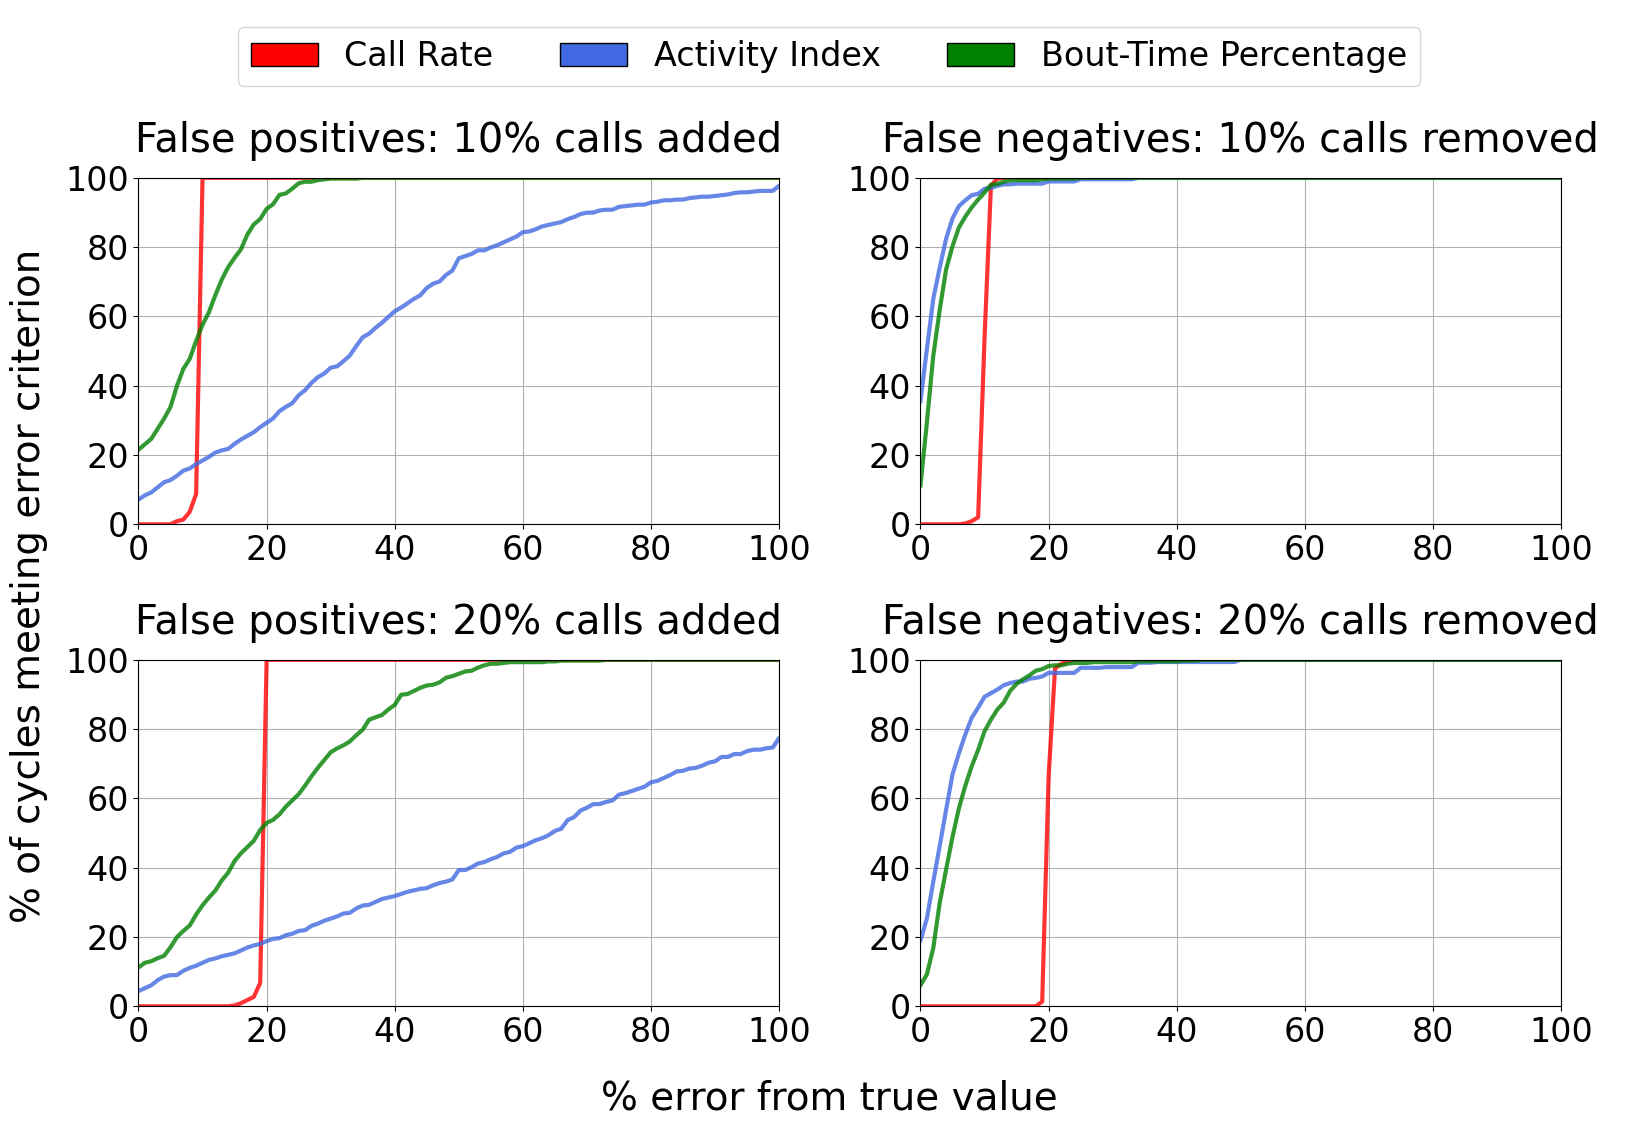

In [71]:
fig, ax = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
plt.rcParams.update({'font.size':24})


plot_frac_list = np.array([0.10, 0.20])
for i, frac in enumerate(plot_frac_list):
    cur_ax = ax[i,0]
    data_params['metric_tag'] = 'call_rate'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'30of30'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'activity_index'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'30of30'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'bout_time_percentage'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'30of30'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)
    cur_ax.set_title(f'False positives: {int(100*frac)}% calls added', y=1.05)
    cur_ax.grid(which='both')

plot_frac_list = np.array([0.9, 0.8])
for i, frac in enumerate(plot_frac_list):
    cur_ax = ax[i,1]
    data_params['metric_tag'] = 'call_rate'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'30of30'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'activity_index'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
    cont_tag = f'30of30'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'bout_time_percentage'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
    cont_tag = f'30of30'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)
    cur_ax.set_title(f'False negatives: {round(100*(1-frac))}% calls removed', y=1.05)
    cur_ax.grid(which='both')

fig.text(0, 0.17, '% of cycles meeting error criterion', ha='center', rotation='vertical', fontsize=plt.rcParams['font.size']+4)
fig.text(0.5, -0.025, '% error from true value', ha='center', fontsize=plt.rcParams['font.size']+4)
fig.tight_layout()

# Create legend patches
CR_patch = patches.Patch(facecolor='red', edgecolor='k', label='Call Rate')
AI_patch = patches.Patch(facecolor='royalblue', edgecolor='k', label='Activity Index')
BTP_patch = patches.Patch(facecolor='green', edgecolor='k', label='Bout-Time Percentage')
legend_patches = [CR_patch, AI_patch, BTP_patch]

# Add legend
legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.075])
legend_ax.axis('off')
legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size'], ncol=3, loc='upper center')

plt.show()

In [72]:
dc_tag = '5of10'
data_params['metric_tag'] = 'bout_time_percentage'
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

Carp LF
Carp LF
Carp LF


In [73]:
dc_tag = '5of10'
data_params['metric_tag'] = 'bout_time_percentage'
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

Carp LF
Carp LF
Carp LF


In [ ]:
def get_continuous_call_rates_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params):
    dc_tag_split = re.findall(r"\d+", metric_col_name)
    dc_tag = re.findall(r"\d+of\d+", metric_col_name)[0]
    cycle_length = int(dc_tag_split[-1])
    cont_tag = f'{cycle_length}of{cycle_length}'
    data_params['cur_dc_tag'] = cont_tag

    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
    location_df = ss.assign_cycle_groups_to_each_call(location_df, cycle_length, data_params)
    num_of_detections = actvt.get_number_of_detections_per_cycle(location_df, cycle_length)
    call_rate = actvt.get_metric_per_time_on(num_of_detections, cycle_length)
    call_rate_cont_column = actvt.filter_and_prepare_metric(call_rate, data_params)
    call_rate_cont_column = call_rate_cont_column.set_index("datetime_UTC")
    ss.are_there_expected_number_of_cycles(location_df, call_rate_cont_column, cycle_length, data_params)

    return call_rate_cont_column

In [43]:
dc_tag

'5of10'

In [48]:
activity_arr = pd.DataFrame()
location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
callrate_arr = comp.get_continuous_call_rates_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params)
callrate_arr

,call_rate (10of10)
datetime_UTC,
2022-07-13 04:50:00,4.3
2022-07-13 05:00:00,3.3
2022-07-13 05:10:00,0.0
2022-07-13 05:20:00,0.5
2022-07-13 05:30:00,2.6
...,...
2022-10-17 13:00:00,0.0
2022-10-17 13:10:00,0.0
2022-10-17 13:20:00,0.0


In [49]:
dc_tag_split = re.findall(r"\d+", metric_col_name)
dc_tag = re.findall(r"\d+of\d+", metric_col_name)[0]
cycle_length = int(dc_tag_split[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params['cur_dc_tag'] = cont_tag

location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
location_df = ss.assign_cycle_groups_to_each_call(location_df, cycle_length, data_params)
location_df

,index_in_file,SNR,peak_frequency,index_in_summary,input_file_dt,freq_group,ref_time,call_start_time,call_end_time,start_time,...,class,class_prob,det_prob,individual,input_file,Site name,Recover Folder,SD Card,File Duration,cycle_ref_time
0,0,19.337273,29760.0,0,2022-07-13 04:30:00,LF,2022-07-13 04:53:00.335500,2022-07-13 04:53:00.335500,2022-07-13 04:53:00.353200,1380.3355,...,Nyctalus leisleri,0.487,0.559,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795.0,2022-07-13 04:50:00
1,1,7.658908,24960.0,1,2022-07-13 04:30:00,LF,2022-07-13 04:55:13.597500,2022-07-13 04:55:13.597500,2022-07-13 04:55:13.612900,1513.5975,...,Nyctalus leisleri,0.449,0.571,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795.0,2022-07-13 04:50:00
2,2,5.029702,24960.0,2,2022-07-13 04:30:00,LF,2022-07-13 04:55:13.823500,2022-07-13 04:55:13.823500,2022-07-13 04:55:13.839600,1513.8235,...,Nyctalus leisleri,0.513,0.591,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795.0,2022-07-13 04:50:00
3,3,8.310447,26880.0,3,2022-07-13 04:30:00,LF,2022-07-13 04:55:13.988500,2022-07-13 04:55:13.988500,2022-07-13 04:55:14.001000,1513.9885,...,Nyctalus leisleri,0.424,0.632,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795.0,2022-07-13 04:50:00
4,4,9.005425,24960.0,4,2022-07-13 04:30:00,LF,2022-07-13 04:55:14.267500,2022-07-13 04:55:14.267500,2022-07-13 04:55:14.283900,1514.2675,...,Nyctalus leisleri,0.459,0.587,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795.0,2022-07-13 04:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012474,72,8.130118,25920.0,1016410,2022-10-17 13:30:00,LF,2022-10-17 13:42:57.365500,2022-10-17 13:42:57.365500,2022-10-17 13:42:57.377900,777.3655,...,Nyctalus leisleri,0.335,0.629,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795.0,2022-10-17 13:40:00
1012475,73,7.821952,24960.0,1016411,2022-10-17 13:30:00,LF,2022-10-17 13:42:58.393500,2022-10-17 13:42:58.393500,2022-10-17 13:42:58.409200,778.3935,...,Nyctalus leisleri,0.518,0.615,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795.0,2022-10-17 13:40:00
1012476,74,4.395280,25920.0,1016412,2022-10-17 13:30:00,LF,2022-10-17 13:42:58.543500,2022-10-17 13:42:58.543500,2022-10-17 13:42:58.558300,778.5435,...,Nyctalus leisleri,0.281,0.548,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795.0,2022-10-17 13:40:00
1012477,75,11.030292,24960.0,1016413,2022-10-17 13:30:00,LF,2022-10-17 13:42:58.794500,2022-10-17 13:42:58.794500,2022-10-17 13:42:58.810800,778.7945,...,Nyctalus leisleri,0.534,0.630,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795.0,2022-10-17 13:40:00


In [78]:
frac = 0.1
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_tag = f'10of10'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme*5

,call_rate (0.1)
datetime_UTC,
2022-07-13 04:30:00,1.0
2022-07-13 04:40:00,0.0
2022-07-13 04:50:00,1.0
2022-07-13 05:00:00,0.0
2022-07-13 05:10:00,1.0
...,...
2022-10-17 13:10:00,0.0
2022-10-17 13:20:00,0.0
2022-10-17 13:30:00,0.0


In [79]:
cont_column*10

,call_rate (10of10)
datetime_UTC,
2022-07-13 04:50:00,43.0
2022-07-13 05:00:00,33.0
2022-07-13 05:10:00,0.0
2022-07-13 05:20:00,5.0
2022-07-13 05:30:00,26.0
...,...
2022-10-17 13:00:00,0.0
2022-10-17 13:10:00,0.0
2022-10-17 13:20:00,0.0


In [54]:
def get_associated_metric_for_cont_column(metric_for_scheme, cont_column):
    if len(cont_column)>len(metric_for_scheme):
        metric_for_scheme_for_comparison = metric_for_scheme.reindex(cont_column.index, fill_value=0)
    else:
        cont_column = cont_column.reindex(metric_for_scheme.index, fill_value=0)
        metric_for_scheme_for_comparison = metric_for_scheme
    comp.does_reindexed_match_original_at_original_indices(metric_for_scheme_for_comparison, metric_for_scheme)
    comp.do_calls_exist_in_reindexed_version(metric_for_scheme_for_comparison)

    return metric_for_scheme_for_comparison

In [56]:
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)

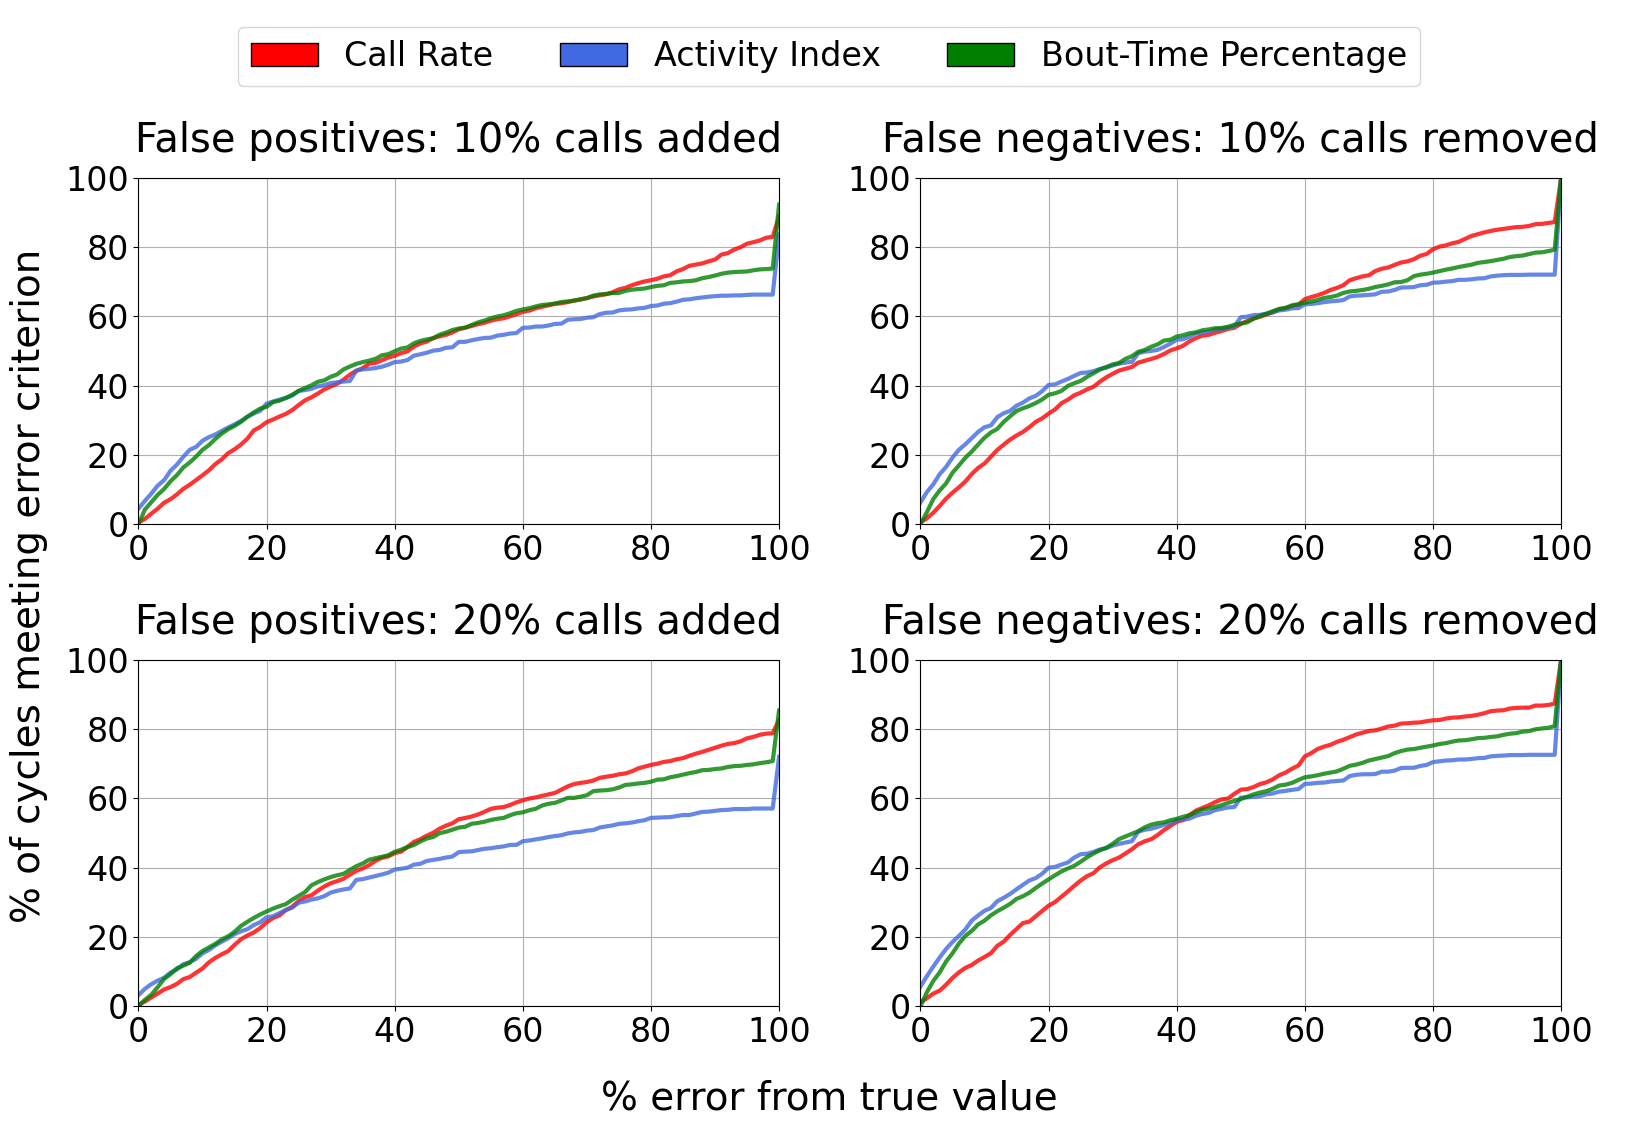

In [74]:
fig, ax = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
plt.rcParams.update({'font.size':24})


plot_frac_list = np.array([0.10, 0.20])
for i, frac in enumerate(plot_frac_list):
    cur_ax = ax[i,0]
    data_params['metric_tag'] = 'call_rate'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'activity_index'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'bout_time_percentage'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)
    cur_ax.set_title(f'False positives: {int(100*frac)}% calls added', y=1.05)
    cur_ax.grid(which='both')

plot_frac_list = np.array([0.9, 0.8])
for i, frac in enumerate(plot_frac_list):
    cur_ax = ax[i,1]
    data_params['metric_tag'] = 'call_rate'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'activity_index'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'bout_time_percentage'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params)
    cur_ax.set_title(f'False negatives: {round(100*(1-frac))}% calls removed', y=1.05)
    cur_ax.grid(which='both')

fig.text(0, 0.17, '% of cycles meeting error criterion', ha='center', rotation='vertical', fontsize=plt.rcParams['font.size']+4)
fig.text(0.5, -0.025, '% error from true value', ha='center', fontsize=plt.rcParams['font.size']+4)
fig.tight_layout()

# Create legend patches
CR_patch = patches.Patch(facecolor='red', edgecolor='k', label='Call Rate')
AI_patch = patches.Patch(facecolor='royalblue', edgecolor='k', label='Activity Index')
BTP_patch = patches.Patch(facecolor='green', edgecolor='k', label='Bout-Time Percentage')
legend_patches = [CR_patch, AI_patch, BTP_patch]

# Add legend
legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.075])
legend_ax.axis('off')
legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size'], ncol=3, loc='upper center')

plt.show()

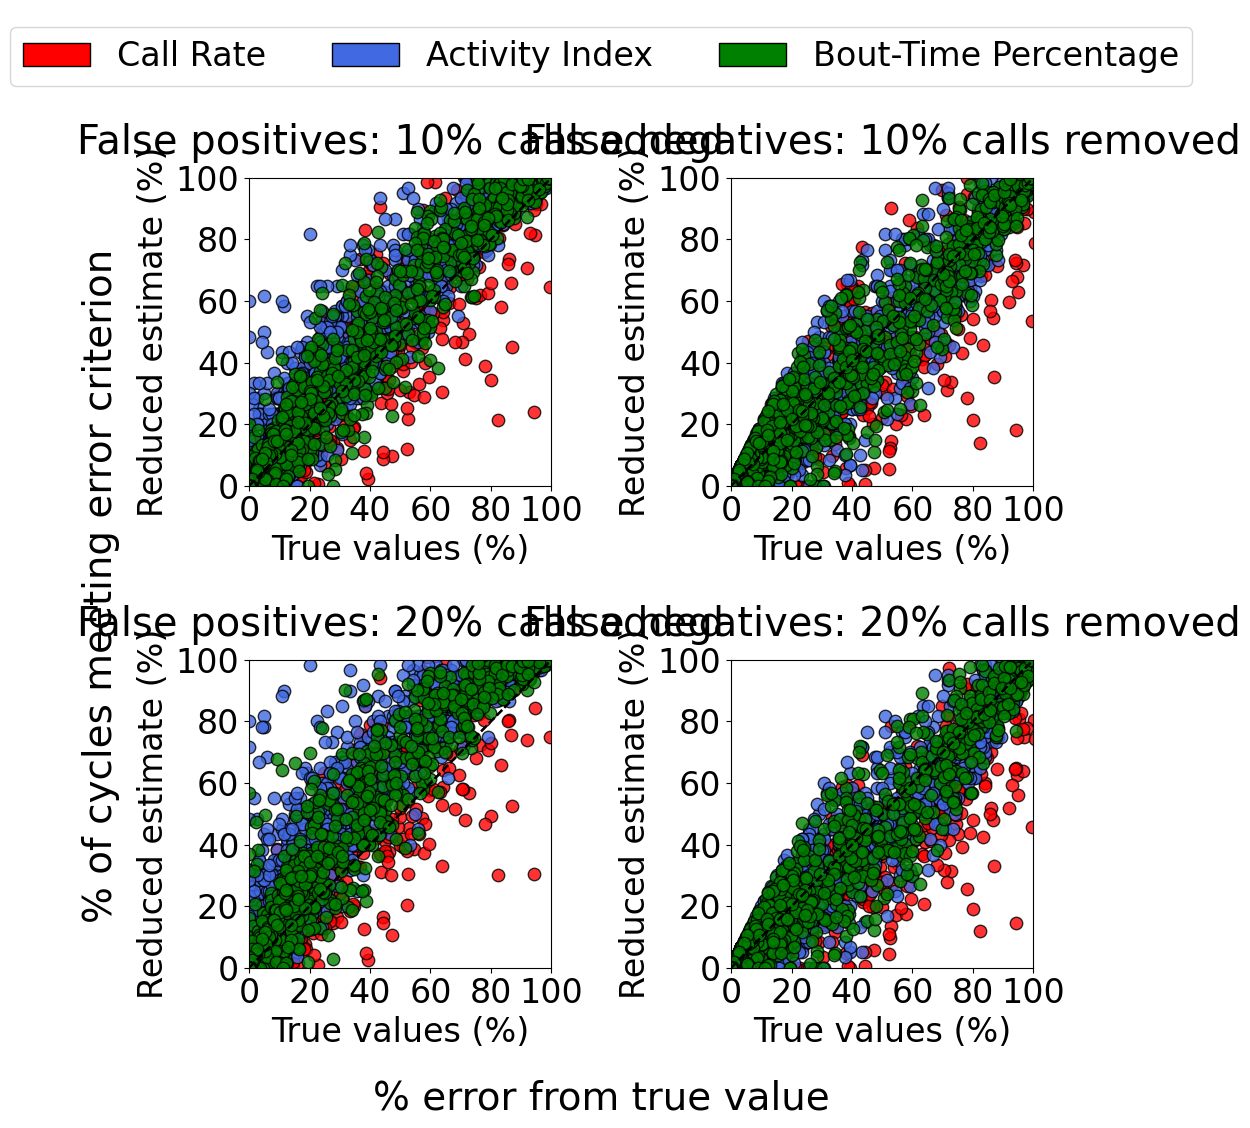

In [77]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
plt.rcParams.update({'font.size':24})


plot_frac_list = np.array([0.10, 0.20])
for i, frac in enumerate(plot_frac_list):
    cur_ax = ax[i,0]
    data_params['metric_tag'] = 'call_rate'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_indiv_dc_control_comp_over_cycle_linear_scale(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'activity_index'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_indiv_dc_control_comp_over_cycle_linear_scale(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'bout_time_percentage'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_indiv_dc_control_comp_over_cycle_linear_scale(cur_ax, plt_dcmetr, plt_cmetr, data_params)
    cur_ax.set_title(f'False positives: {int(100*frac)}% calls added', y=1.05)
    cur_ax.grid(which='both')

plot_frac_list = np.array([0.9, 0.8])
for i, frac in enumerate(plot_frac_list):
    cur_ax = ax[i,1]
    data_params['metric_tag'] = 'call_rate'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_indiv_dc_control_comp_over_cycle_linear_scale(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'activity_index'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_indiv_dc_control_comp_over_cycle_linear_scale(cur_ax, plt_dcmetr, plt_cmetr, data_params)

    data_params['metric_tag'] = 'bout_time_percentage'
    data_params['index_time_block_in_secs'] = 5
    metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
    cont_tag = f'10of10'
    cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
    metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
    cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
    metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
    plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
    plot_indiv_dc_control_comp_over_cycle_linear_scale(cur_ax, plt_dcmetr, plt_cmetr, data_params)
    cur_ax.set_title(f'False negatives: {round(100*(1-frac))}% calls removed', y=1.05)
    cur_ax.grid(which='both')

fig.text(0, 0.17, '% of cycles meeting error criterion', ha='center', rotation='vertical', fontsize=plt.rcParams['font.size']+4)
fig.text(0.5, -0.025, '% error from true value', ha='center', fontsize=plt.rcParams['font.size']+4)
fig.tight_layout()

# Create legend patches
CR_patch = patches.Patch(facecolor='red', edgecolor='k', label='Call Rate')
AI_patch = patches.Patch(facecolor='royalblue', edgecolor='k', label='Activity Index')
BTP_patch = patches.Patch(facecolor='green', edgecolor='k', label='Bout-Time Percentage')
legend_patches = [CR_patch, AI_patch, BTP_patch]

# Add legend
legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.075])
legend_ax.axis('off')
legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size'], ncol=3, loc='upper center')

plt.show()